# NFL Blitz Predictor — EDA

Exploring Big Data Bowl 2023 data to understand:
1. How blitzes are distributed across game situations
2. Which pre-snap features look predictive
3. Class balance and data quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA = Path('../../data')

## Load data

In [2]:
games = pd.read_csv(DATA / 'games.csv')
plays = pd.read_csv(DATA / 'plays.csv')
pff = pd.read_csv(DATA / 'pffScoutingData.csv')

print('games:', games.shape)
print('plays:', plays.shape)
print('pff:  ', pff.shape)

games: (122, 7)
plays: (8557, 32)
pff:   (188254, 15)


## Build the blitz label

In [3]:
rushers = (pff[pff['pff_role'] == 'Pass Rush']
           .groupby(['gameId', 'playId']).size()
           .rename('num_pass_rushers').reset_index())
rushers['was_blitz'] = (rushers['num_pass_rushers'] >= 5).astype(int)

print(f"Overall blitz rate: {rushers['was_blitz'].mean():.1%}")
rushers['num_pass_rushers'].value_counts().sort_index()

Overall blitz rate: 24.6%


num_pass_rushers
1       2
2      16
3     420
4    6011
5    1689
6     348
7      69
8       1
Name: count, dtype: int64

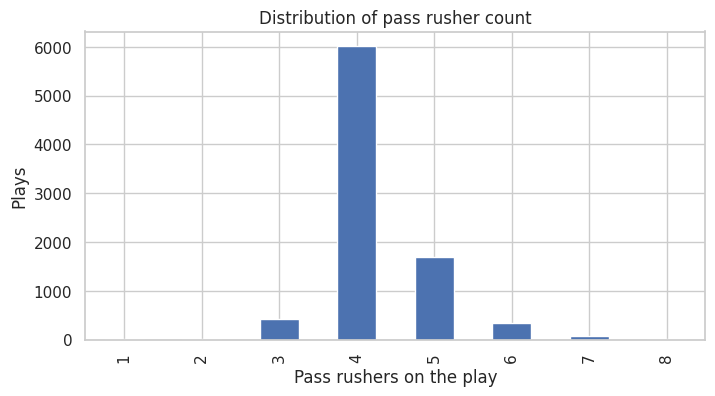

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
rushers['num_pass_rushers'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Pass rushers on the play')
ax.set_ylabel('Plays')
ax.set_title('Distribution of pass rusher count')
plt.show()

## Blitz rate by situation

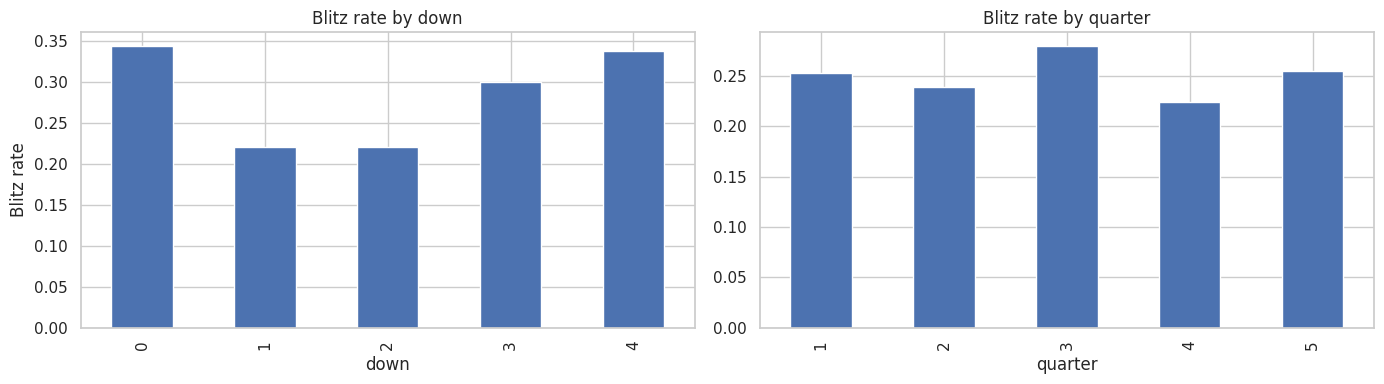

In [5]:
df = plays.merge(rushers, on=['gameId', 'playId'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby('down')['was_blitz'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Blitz rate by down')
axes[0].set_ylabel('Blitz rate')

df.groupby('quarter')['was_blitz'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Blitz rate by quarter')
plt.tight_layout()
plt.show()

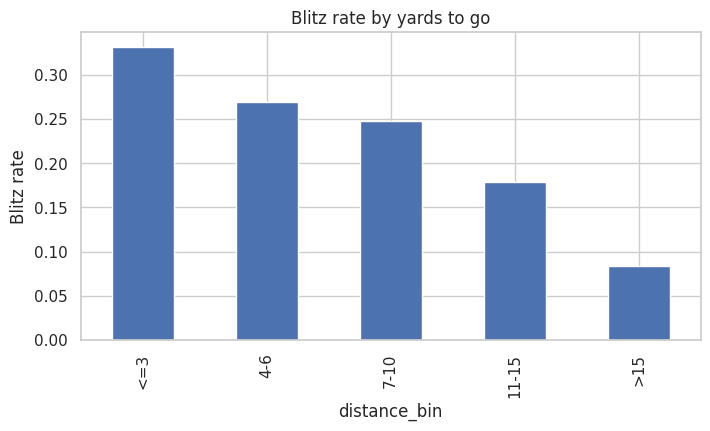

In [6]:
bins = [0, 3, 6, 10, 15, 100]
labels_ = ['<=3', '4-6', '7-10', '11-15', '>15']
df['distance_bin'] = pd.cut(df['yardsToGo'], bins=bins, labels=labels_)

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('distance_bin', observed=True)['was_blitz'].mean().plot(kind='bar', ax=ax)
ax.set_title('Blitz rate by yards to go')
ax.set_ylabel('Blitz rate')
plt.show()

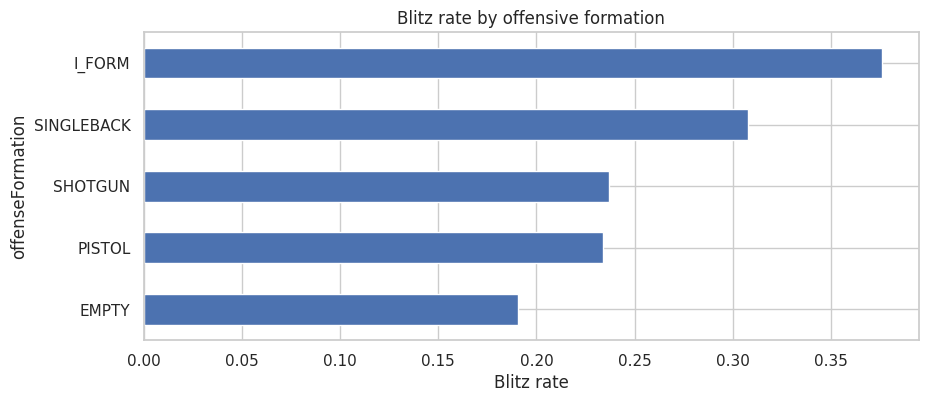

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('offenseFormation')['was_blitz'].agg(['mean', 'count']).query('count > 50') \
    .sort_values('mean')['mean'].plot(kind='barh', ax=ax)
ax.set_title('Blitz rate by offensive formation')
ax.set_xlabel('Blitz rate')
plt.show()

## Defensive team tendencies

In [8]:
team_blitz = df.groupby('defensiveTeam')['was_blitz'].agg(['mean', 'count']).sort_values('mean', ascending=False)
team_blitz.head(10)

,mean,count
defensiveTeam,,
TB,0.395062,324
DEN,0.353383,266
MIA,0.349153,295
WAS,0.337662,308
CAR,0.330798,263
BAL,0.325581,258
KC,0.319392,263
NYJ,0.311741,247
ARI,0.301887,265


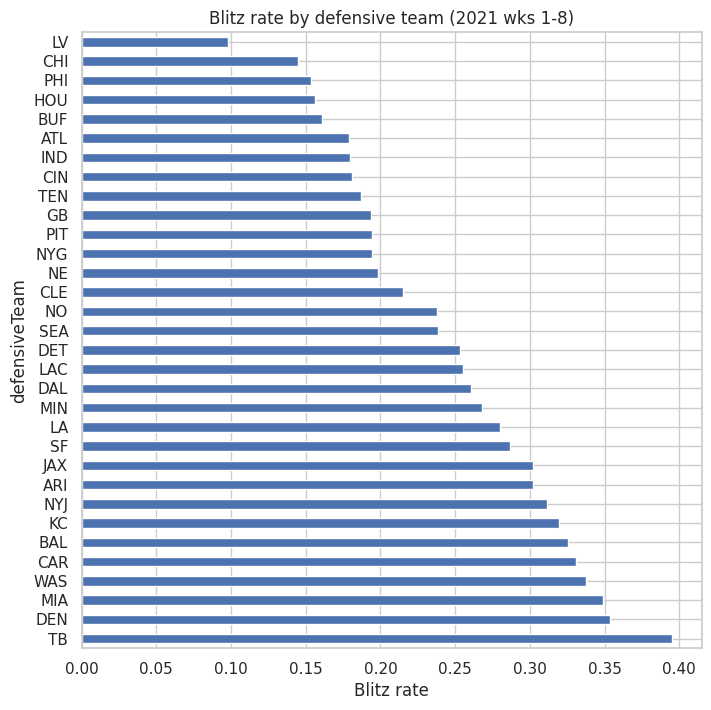

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
team_blitz['mean'].plot(kind='barh', ax=ax)
ax.set_title('Blitz rate by defensive team (2021 wks 1-8)')
ax.set_xlabel('Blitz rate')
plt.show()